# **종합실습1 이변량분석(y-숫자) : car seat 매출 분석**

* 카시트에 대해서 지역 매장 별 매출액을 예측하고자 합니다.

![](https://cdn.images.express.co.uk/img/dynamic/24/590x/child-car-seat-986556.jpg?r=1532946857754)

## **1.환경준비**

### **(1) 라이브러리 로딩**

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as spst

### **(2) 데이터 로딩**

|	변수명	|	설명	|	구분	|
|----|----|----|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target	|
|	CompPrice 	|	지역별 경쟁사 판매가격(달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격(달러)	|	feature	|
|	ShelveLoc 	|	 진열상태	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부	|	feature	|
|	Income 	|	 지역 주민 평균 소득	|	feature	|
|	Urban 	|	 매장이 도시에 있는지 여부	|	feature	|



In [9]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/Carseats2.csv'
data = pd.read_csv(path)
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


In [13]:
target = 'Sales'  # 타겟 변수 -> 매출에 영향을 준 것이 무엇인가?를 알기 위함

## **2.숫자형 X --> Y**

* 모든 숫자형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : scatter, jointplot  
② 수치화 : 상관분석

In [21]:
def eda_2_nn(data, x, y):
    result = spst.pearsonr(data[x], data[y])  # 상관분석을 해서 상관계수가 p-value에 담기게 된다. 
    print(f'r : {result[0]}')
    print(f'pv : {result[1]}')
    sns.scatterplot(x = x, y = y, data = data)
    plt.grid()
    plt.show()

### **(1) Advertising -> Sales**

1) 시각화 : scatter(regplot), jointplot

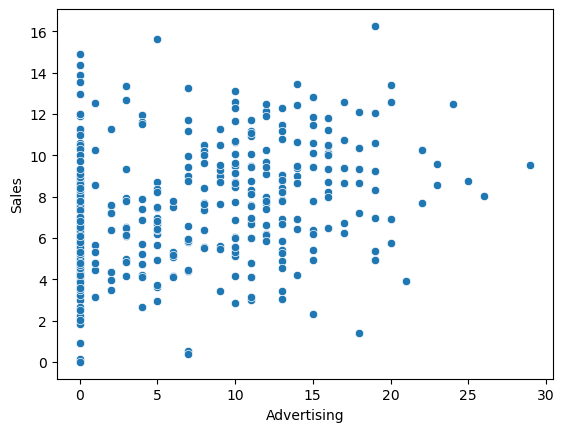

In [15]:
var = 'Advertising'

sns.scatterplot(x=var, y = target, data = data)
plt.show()

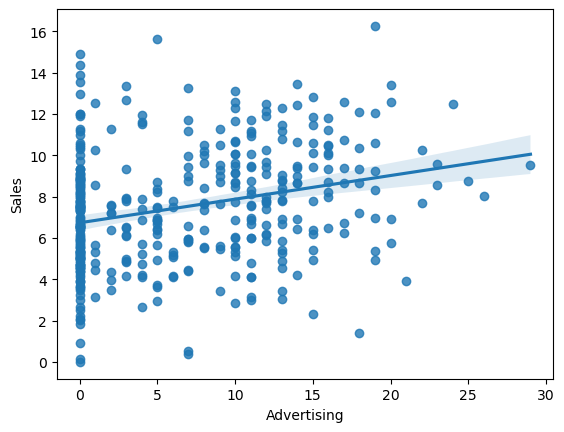

In [17]:
sns.regplot(x=var, y = target, data = data)
plt.show()

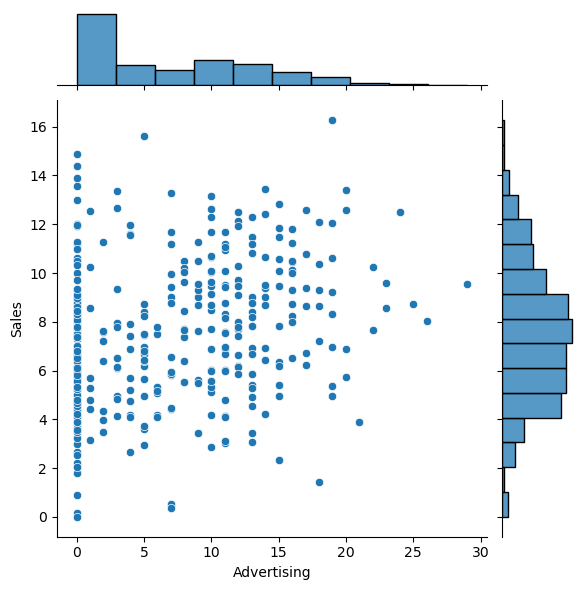

In [18]:
sns.jointplot(x=var, y = target, data = data)
plt.show()

r : 0.269506781376902
pv : 4.3776771103027514e-08


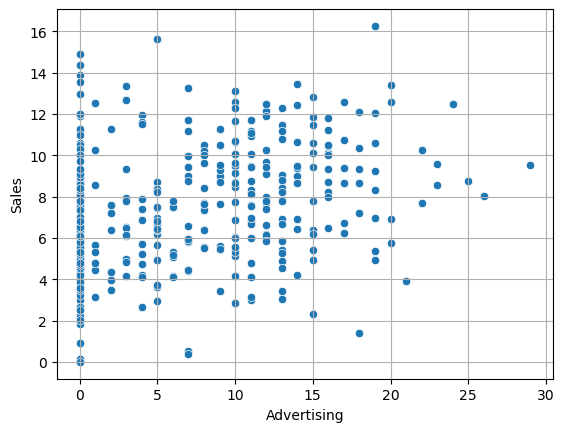

In [23]:
# 광고비가 증가할수록 판매량이 증가하는 경향이 보인다.(우측 상향)
# r(상관계수)를 확인해보니 중간정도의 관계가 있다.(아주 약하지도 강하지도 않은..!) ->   "-1 <= r <= 1"   /  0 <= |r| <= 1

var = 'Advertising'  # 광고비 예산
eda_2_nn(data, var, target)

2) 수치화 : 상관분석

In [ ]:
result = spst.pearsonr(data[var], data[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

* 광고비와 판매량은 관련이 있다. 그러나 크지 않다.

* 추가 : 광고비 0 빼고 분석해보기

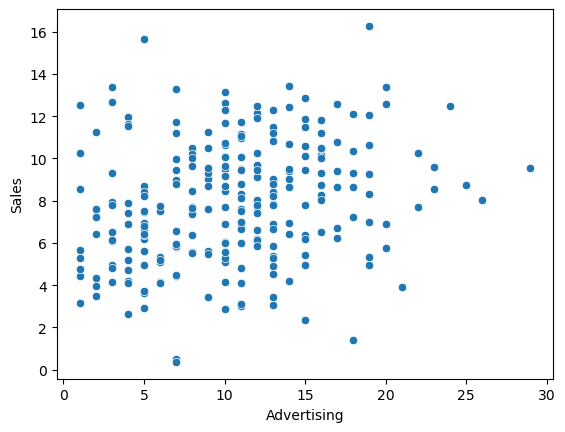

In [25]:
temp = data.loc[data['Advertising'] > 0]
sns.scatterplot(x=var, y = target, data = temp)
plt.show()

In [27]:
result = spst.pearsonr(temp[var], temp[target])
print(f'상관계수 : {result[0]}, p-value : {result[1]}')

상관계수 : 0.2571829256169392, p-value : 3.112672883086058e-05


### **(2) Population -> Sales**

1) 시각화 : scatter(regplot), jointplot

In [ ]:
# 관련이 없다고 보인다.

2) 수치화 : 상관분석

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

### **(3) Price -> Sales**

1) 시각화 : scatter(regplot), jointplot

r : -0.4449507278465726
pv : 7.618187011913169e-21


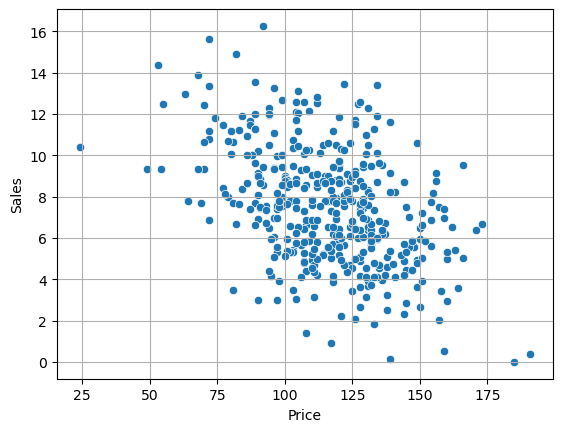

In [38]:
# 상관계수 높은 편
# 관련이 있다고 볼 수 있다.

var = 'Price'
eda_2_nn(data, var, target)

2) 수치화 : 상관분석

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

### **(4) Age -> Sales**

1) 시각화 : scatter(regplot), jointplot

r : -0.2318154396045765
pv : 2.7889498393714038e-06


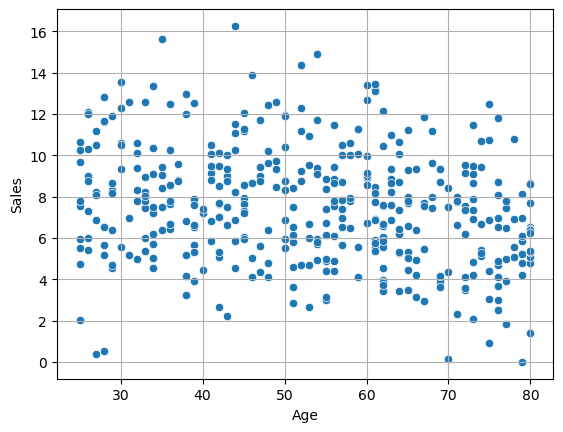

In [29]:
# 나이가 많을수록 판매량이 적다.
# 나이가 증가할수록 판매량이 줄어드는 경향이 있다.
# 그래프 모양이 우하양이다. 
# p-value가 0.05보다 작기 때문에 유의하다.
# 우리 눈에 보이는 것이 전부는 아니다.

var = 'Age'
eda_2_nn(data, var, target)

2) 수치화 : 상관분석

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

### **(5) CompPrice -> Sales**
지역별 경쟁사 판매가격(달러)

1) 시각화 : scatter(regplot), jointplot

r : 0.06407872955062152
pv : 0.2009398289418404


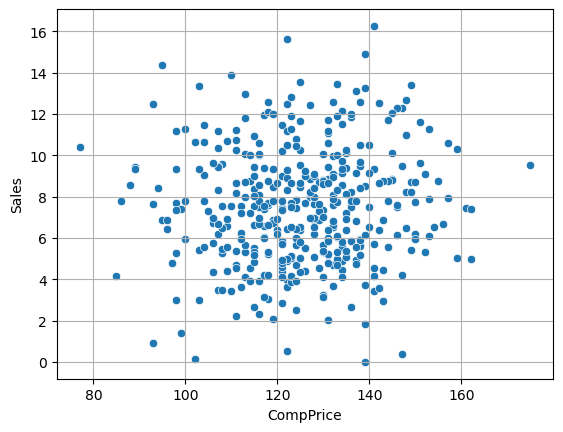

In [41]:
# 상관계수 0과 같으니 CompPrice는 판매량에 관련이 없다.
# p-value가 0.05보다 높으므로 CompPrice는 판매량에 관련이 없다.

var = 'CompPrice'
eda_2_nn(data, var, target)

2) 수치화 : 상관분석

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

* 다른 제품 두개가 있다면 두가지를 비교해서 구매하게 된다. (가격 비교)
* 두 제품 사이의 차이를 본다.

In [44]:
# 가격차이 = 가격경쟁력
data['price_diff'] = data['CompPrice'] - data['Price']  # '-'가 나올 수 있는데 그건 문제가 있기 때문에 회사에서 개선이 필요하다.(자사가 더 비싼 것이기 때문에)
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US,price_diff
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes,18
1,11.22,111,48,16,260,83,Good,65,Yes,Yes,28
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes,33
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes,20
4,4.15,141,64,3,340,128,Bad,38,Yes,No,13


r : 0.5979217124533921
pv : 3.877120641788767e-40


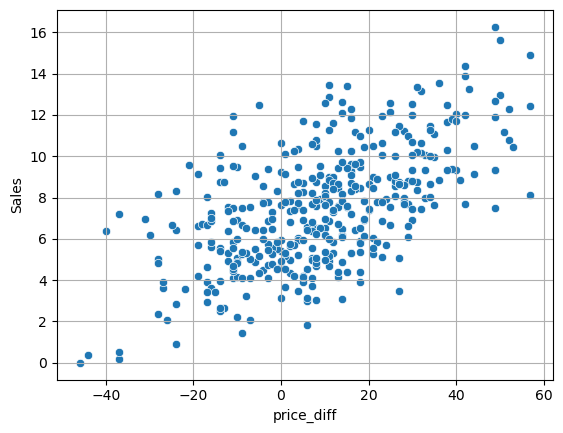

In [46]:
# 분석
var = 'price_diff'   # 타사-자사 제품 가격 차이
eda_2_nn(data, var, target)

# 위에서(CompPrice-Sales)와 달리 강한 상관관계가 되었다.
# 고객 입장에서 구매를 할지 말지 영향력을 주는 것은 두 제품의 가격 차이라는 사실을 알 수 있다. 
# 자사,타사의 가격 차이와 판매량의 상관분석을 해보니 높아졌기 때문이다.

# 해당 결과를 4사분면으로 나눠서 집단을 구성한 후 추가 분석 가능
# 가격 경쟁력이 높은 곳에서도 잘 팔리는 곳이 있고, 상대적으로 안 팔리는 곳도 있다. 이것까지 함께 분석하면 더 많은 정보를 알 수 있을 것이다.
# 우선순위를 정해서 분석하면 좋다.

### **(6) Income -> Sales**

1) 시각화 : scatter(regplot), jointplot

In [ ]:
# 상관관계가 있는데 강하진 않고 약하다. 약한 상관관계 존재 

2) 수치화 : 상관분석

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

## **3.범주형 X --> Y**

* 모든 범주형 X에 대해서 Y와 비교하여 차트를 그리고 수치화 하시오.

① 시각화 : 평균비교 barplot  
② 수치화 : t-test, anova

### **(1) ShelveLoc-> Sales**

1) 시각화 : 평균비교 barplot

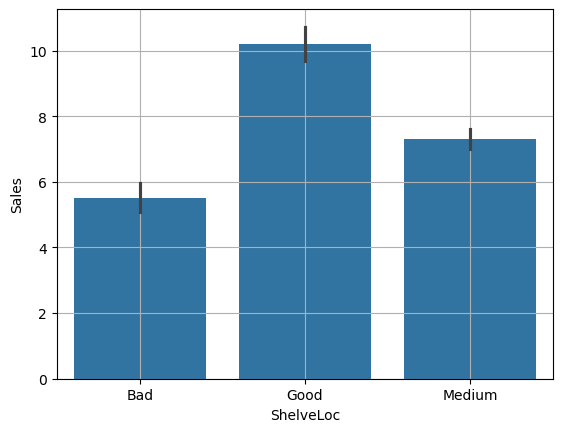

In [53]:
var = 'ShelveLoc'

sns.barplot(x=var, y=target, data = data)
plt.grid()
plt.show()

2) 수치화 : t-test, anova

In [55]:
d_b = data.loc[data[var]=='Bad', target]
d_m = data.loc[data[var]=='Medium', target]
d_g = data.loc[data[var]=='Good', target]

spst.f_oneway(d_b, d_m, d_g)

F_onewayResult(statistic=92.22990509910348, pvalue=1.26693609015938e-33)

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

### **(2) Urban -> Sales**

1) 시각화 : 평균비교 barplot

In [57]:
target

'Sales'

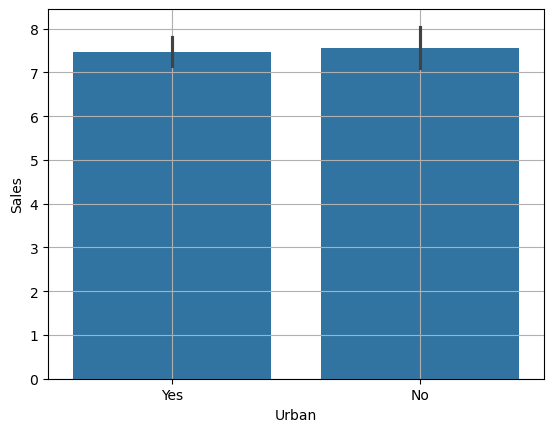

In [85]:
# 관계가 없다.
var = 'Urban'

sns.barplot(x=var, y=target, data = data)
plt.grid()
plt.show()

2) 수치화 : t-test, anova

In [87]:
## t-test
# 두 그룹으로 데이터 저장
gr1 = data.loc[data[var]=='Yes', target]
gr2 = data.loc[data[var]=='No', target]

spst.ttest_ind(gr1, gr2)

TtestResult(statistic=-0.30765346670661126, pvalue=0.7585069603942775, df=398.0)

In [70]:
# anova

p = []
for i in ['Yes','No']:
    t=data.loc[data[var]==i, target]
    p.append(t)

spst.f_oneway(*p)

F_onewayResult(statistic=0.09465065557659712, pvalue=0.7585069603942085)

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- Yes, No의 평균 차이가 거의 없다.
- 그러므로 아무 관련이 없다고 볼 수 있다.
- p-value가 0.005보다 크므로 신뢰하지 않는다.

### **(3) US-> Sales**

1) 시각화 : 평균비교 barplot

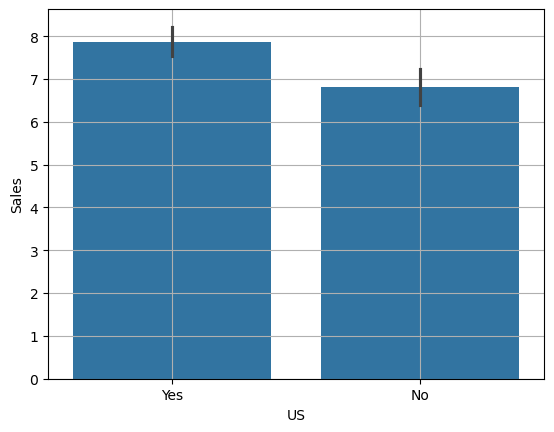

In [93]:
var1 = 'US'

sns.barplot(x=var1, y=target, data = data)
plt.grid()
plt.show()

2) 수치화 : t-test, anova

In [91]:
## t-test
# 두 그룹으로 데이터 저장
gr1_1 = data.loc[data[var1]=='Yes', target]
gr2_1 = data.loc[data[var1]=='No', target]

spst.ttest_ind(gr1_1, gr2_1)  # df는 자유도(degree of freedom)를 의미한다.

TtestResult(statistic=3.589738747802499, pvalue=0.00037233958701471517, df=398.0)

In [76]:
# anova

p = []
for i in ['Yes','No']:
    t=data.loc[data[var1]==i, target]
    p.append(t)

spst.f_oneway(*p)

F_onewayResult(statistic=12.886224277474618, pvalue=0.0003723395870148404)

3) 시각화와 수치화 결과로부터 파악한 내용을 적어 봅시다.

- Yes, No의 평균 차이가 거의 없다.
- statistic=3.589738747802499을 보면 차이가 있구나를 알 수 있다.

## **4.관계 정리하기**

① 강한관계

In [ ]:
# Price_Diff, ShelveLoc

② 중간관계

In [ ]:
# Advertising, Price, Age, Income, US

③ 관계없음

In [ ]:
# Population, Urban